# Notebook 3 — Graph-Spectral Detectability and Null Calibration
### Detectability-Aware Post-Merger GW Anomaly Screening — Project Notebook 3

This notebook builds the Stage-1 detectability statistics used later in the pipeline. It:

- restricts the CQT to the 1.5–4 kHz analysis band;
- normalizes CQT tiles against `calib_block` noise;
- computes graph-spectral and simpler power-based statistics;
- calibrates empirical null thresholds on `calib_block`;
- compares the graph statistic with excess-power baselines;
- measures detection probability over the `(SNR, tau)` grid using `train_block`.

`test_block` is not used here.

### Terminology

Here **BBP-inspired** refers to the detectability idea of a structured component separating from a
calibrated noise background. This notebook does not implement Christopher Moore's stochastic-block-model
community-detection algorithm.

The main graph statistic is `norm_lambda1`, the leading eigenvalue of a local time-frequency graph built
from the empirically normalized excess map `Z_pos`. `raw_lambda1` and `total_power_raw` are retained as
baselines. Section 7 checks directly how strongly the graph statistic tracks total power.

This notebook handles Stage 1 only; damping-time scoring is done later in the pipeline.


In [ ]:
# ---------------------------------------------------------------------------
# 0. Installs
# ---------------------------------------------------------------------------
!pip install -q librosa


## 1. Load Notebook 1 artifacts

Load the operational PSD and the three raw L1 noise pools used in the remaining sections. Core whitening,
signal-generation, and injection functions are defined locally so the notebook can run on its own.


In [ ]:
# ---------------------------------------------------------------------------
# 1. Imports, config, load Notebook 1 artifacts
# ---------------------------------------------------------------------------
import os
import json
import numpy as np
import scipy.sparse
import scipy.sparse.linalg
import scipy.sparse.csgraph
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import librosa
from google.colab import drive; drive.mount('/content/drive')



SEED = 42
rng = np.random.default_rng(SEED)

NB1_DIR = '/content/drive/MyDrive/gw_postmerger/nb1_artifacts'
OUT_DIR = '/content/drive/MyDrive/gw_postmerger/nb3_artifacts'
os.makedirs(OUT_DIR, exist_ok=True)

assert os.path.isdir(NB1_DIR), f"{NB1_DIR} not found; run Notebook 1 first."

FS = 16384
WINDOW_DUR = 0.1
N_SAMPLES_WINDOW = int(FS * WINDOW_DUR)

F_LOW = 20.0
F_HIGH = 6000.0
EDGE_TRIM_S = 4.0
PAD_SAMPLES = int(round(EDGE_TRIM_S * FS))

BLOCKS = json.load(open(os.path.join(NB1_DIR, "gps_blocks.json")))
_psd_npz = np.load(os.path.join(NB1_DIR, "estimated_psd.npz"))
psd_freqs, psd_values = _psd_npz["freqs"], _psd_npz["psd"]
assert np.all(np.isfinite(psd_values)) and np.all(psd_values > 0)

_psd_interp = interp1d(psd_freqs, psd_values, bounds_error=False,
                        fill_value=(psd_values[0], psd_values[-1]))

def whiten(data, fs=FS, psd_interp=_psd_interp, f_low=F_LOW, f_high=F_HIGH):
    assert np.all(np.isfinite(data)), "whiten(): input contains non-finite values."
    n = len(data)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    passband = (freqs >= f_low) & (freqs <= f_high)
    asd = np.sqrt(psd_interp(freqs[passband]))
    assert np.all(np.isfinite(asd)) and np.all(asd > 0)
    data_fft = np.fft.rfft(data)
    whitened_fft = np.zeros_like(data_fft)
    whitened_fft[passband] = data_fft[passband] / asd
    out = np.fft.irfft(whitened_fft, n=n)
    assert np.all(np.isfinite(out)), "whiten(): output contains non-finite values."
    return out

def generate_signal(f_peak, tau, amplitude=1.0, phi=0.0, fs=FS, n_samples=N_SAMPLES_WINDOW):
    t = np.arange(n_samples) / fs
    return amplitude * np.exp(-t / tau) * np.sin(2 * np.pi * f_peak * t + phi)

def compute_snr(h_t, psd_interp=_psd_interp, fs=FS, f_low=F_LOW, f_high=F_HIGH):
    n = len(h_t)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    passband = (freqs >= f_low) & (freqs <= f_high)
    h_fft = np.fft.rfft(h_t) / fs
    df = freqs[1] - freqs[0]
    rho2 = 4.0 * np.sum(np.abs(h_fft[passband])**2 / psd_interp(freqs[passband])) * df
    return np.sqrt(rho2)

def scale_to_snr(h_t, target_snr, psd_interp=_psd_interp, fs=FS):
    base = compute_snr(h_t, psd_interp=psd_interp, fs=fs)
    assert base > 0
    return h_t * (target_snr / base)

raw_noise_pools = {}
for name in ['calib_block', 'train_block', 'test_block']:
    arr = np.load(os.path.join(NB1_DIR, f"raw_{name}_L1.npy"))
    assert np.all(np.isfinite(arr)), f"{name}: raw noise pool contains non-finite values."
    raw_noise_pools[name] = arr
    print(f"{name:12s}: loaded {len(arr)} samples ({len(arr)/FS:.0f}s) of raw noise")

def inject_and_whiten(block_name, f_peak, tau, target_snr, rng=rng,
                       fs=FS, window_samples=N_SAMPLES_WINDOW, pad_samples=PAD_SAMPLES):
    pool = raw_noise_pools[block_name]
    local_len = window_samples + 2 * pad_samples
    start_idx = rng.integers(0, len(pool) - local_len)
    local_noise = pool[start_idx: start_idx + local_len].astype(np.float64)
    local_noise = local_noise - local_noise.mean()
    h_t = generate_signal(f_peak, tau, fs=fs, n_samples=window_samples)
    h_scaled = scale_to_snr(h_t, target_snr, fs=fs)
    injected_local = local_noise.copy()
    injected_local[pad_samples: pad_samples + window_samples] += h_scaled
    whitened_local = whiten(injected_local, fs=fs)
    interior = whitened_local[pad_samples: pad_samples + window_samples]
    assert len(interior) == window_samples
    assert np.all(np.isfinite(interior))
    return interior, h_scaled, start_idx

def make_noise_only_window(block_name, rng=rng, fs=FS, window_samples=N_SAMPLES_WINDOW,
                            pad_samples=PAD_SAMPLES):
    pool = raw_noise_pools[block_name]
    local_len = window_samples + 2 * pad_samples
    start_idx = rng.integers(0, len(pool) - local_len)
    local_noise = pool[start_idx: start_idx + local_len].astype(np.float64)
    local_noise = local_noise - local_noise.mean()
    whitened_local = whiten(local_noise, fs=fs)
    interior = whitened_local[pad_samples: pad_samples + window_samples]
    assert np.all(np.isfinite(interior))
    return interior, start_idx

print(f"\nWhitening passband: [{F_LOW}, {F_HIGH}] Hz")


Mounted at /content/drive
calib_block : loaded 16777216 samples (1024s) of raw noise
train_block : loaded 16777216 samples (1024s) of raw noise
test_block  : loaded 16777216 samples (1024s) of raw noise

Whitening passband: [20.0, 6000.0] Hz


## 2. Band-restricted CQT

Compute the CQT over 500–8000 Hz and retain bins whose center frequencies fall in the 1500–4000 Hz
post-merger band. All statistics below use this band-restricted map.


In [ ]:
# ---------------------------------------------------------------------------
# 2. Band-restricted CQT
# ---------------------------------------------------------------------------
CQT_FMIN = 500.0
CQT_N_BINS = 48
CQT_BINS_PER_OCTAVE = 12
CQT_HOP_LENGTH = 8
CQT_BAND_LOW = 1500.0  # Hz
CQT_BAND_HIGH = 4000.0  # Hz

_cqt_all_freqs = librosa.cqt_frequencies(n_bins=CQT_N_BINS, fmin=CQT_FMIN, bins_per_octave=CQT_BINS_PER_OCTAVE)
_cqt_band_mask = (_cqt_all_freqs >= CQT_BAND_LOW) & (_cqt_all_freqs <= CQT_BAND_HIGH)
cqt_band_freqs = _cqt_all_freqs[_cqt_band_mask]
print(f"CQT bins in [{CQT_BAND_LOW}, {CQT_BAND_HIGH}] Hz: {_cqt_band_mask.sum()} of {CQT_N_BINS} total "
      f"(center frequencies: {np.round(cqt_band_freqs, 1).tolist()})")

def compute_cqt_banded(whitened_window, fs=FS, fmin=CQT_FMIN, n_bins=CQT_N_BINS,
                        bins_per_octave=CQT_BINS_PER_OCTAVE, hop_length=CQT_HOP_LENGTH,
                        band_mask=_cqt_band_mask):
    """Return the CQT magnitude restricted to the analysis band."""
    C = librosa.cqt(whitened_window, sr=fs, fmin=fmin, n_bins=n_bins,
                     bins_per_octave=bins_per_octave, hop_length=hop_length)
    return np.abs(C)[band_mask, :]


CQT bins in [1500.0, 4000.0] Hz: 17 of 48 total (center frequencies: [1587.4, 1681.8, 1781.8, 1887.7, 2000.0, 2118.9, 2244.9, 2378.4, 2519.8, 2669.7, 2828.4, 2996.6, 3174.8, 3363.6, 3563.6, 3775.5, 4000.0])


## 3. Empirical CQT normalization

Build a reference distribution from `calib_block` noise-only windows. For each CQT tile, use the median
and scaled median absolute deviation of `log1p(CQT)`:

$$Z = \frac{\log(1+\mathrm{CQT})-\mathrm{median}}{\mathrm{MAD}}, \qquad
Z_{\rm pos} = \max(Z,0).$$

The normalized graph statistics are computed from `Z_pos`.


In [ ]:
# ---------------------------------------------------------------------------
# 3. Empirical CQT normalization (calib_block only)
# ---------------------------------------------------------------------------
N_NORM_SAMPLES = 500

_norm_stack = []
for i in range(N_NORM_SAMPLES):
    w, _ = make_noise_only_window('calib_block')
    mag = compute_cqt_banded(w)
    _norm_stack.append(np.log1p(mag))
    if (i + 1) % 250 == 0:
        print(f"  normalization sample {i+1}/{N_NORM_SAMPLES}...")
_norm_stack = np.stack(_norm_stack, axis=0)  # samples x frequency x time

cqt_bin_median = np.median(_norm_stack, axis=0)
cqt_bin_mad = np.median(np.abs(_norm_stack - cqt_bin_median[None, :, :]), axis=0)
cqt_bin_mad_safe = np.maximum(1.4826 * cqt_bin_mad, 1e-6)  # Gaussian-equivalent MAD scale
del _norm_stack

print(f"\nNormalization: {N_NORM_SAMPLES} calib_block noise windows, shape "
      f"{cqt_bin_median.shape} (n_freq_band x n_time).")
print(f"Median MAD (scaled): {np.median(cqt_bin_mad_safe):.4f}")

def normalize_cqt(mag):
    z = (np.log1p(mag) - cqt_bin_median) / cqt_bin_mad_safe
    return np.maximum(z, 0.0)


  normalization sample 250/500...
  normalization sample 500/500...

Normalization: 500 calib_block noise windows, shape (17, 205) (n_freq_band x n_time).
Median MAD (scaled): 0.5599


## 4. Graph construction and window statistics

For each window, build one local graph from the raw band-restricted CQT magnitude and another from
`Z_pos`. Neighboring tile values are multiplied to form edge weights.

The statistics saved for each window are:

- `total_power_raw`, `max_tile_raw`;
- `total_power_norm`, `max_tile_norm`;
- `raw_lambda1`, `norm_lambda1`;
- `largest_cc`, the largest connected component above the normalized-tile threshold.

`leading_eigenvalue()` returns zero for an empty graph and otherwise uses the sparse eigensolver, with a
dense fallback if needed.


In [ ]:
# ---------------------------------------------------------------------------
# 4. Graph construction + statistics bundle
# ---------------------------------------------------------------------------
GRAPH_FREQ_RADIUS = 2
GRAPH_TIME_RADIUS = 2
CC_THRESHOLD = 2.0        # Z_pos threshold for the largest-connected-component baseline
CC_FREQ_RADIUS = 1
CC_TIME_RADIUS = 1

def build_tf_graph(tf_map, freq_radius=GRAPH_FREQ_RADIUS, time_radius=GRAPH_TIME_RADIUS):
    """Build a sparse local time-frequency adjacency matrix."""
    n_freq, n_time = tf_map.shape
    n = n_freq * n_time
    idx_grid = np.arange(n).reshape(n_freq, n_time)
    rows, cols, data = [], [], []
    for df in range(-freq_radius, freq_radius + 1):
        for dt in range(-time_radius, time_radius + 1):
            if df == 0 and dt == 0:
                continue
            f_src = slice(max(0, -df), n_freq - max(0, df))
            f_dst = slice(max(0, df), n_freq - max(0, -df))
            t_src = slice(max(0, -dt), n_time - max(0, dt))
            t_dst = slice(max(0, dt), n_time - max(0, -dt))
            src_idx = idx_grid[f_src, t_src].reshape(-1)
            dst_idx = idx_grid[f_dst, t_dst].reshape(-1)
            w = (tf_map[f_src, t_src] * tf_map[f_dst, t_dst]).reshape(-1)
            rows.append(src_idx); cols.append(dst_idx); data.append(w)
    rows = np.concatenate(rows); cols = np.concatenate(cols); data = np.concatenate(data)
    return scipy.sparse.csr_matrix((data, (rows, cols)), shape=(n, n))

def leading_eigenvalue(A):
    """Return the leading eigenvalue, with a dense fallback if the sparse solver fails."""
    if A.nnz == 0:
        return 0.0
    try:
        val = scipy.sparse.linalg.eigsh(A, k=1, which='LA', return_eigenvectors=False)
        return float(val[0])
    except Exception:
        dense = A.toarray()
        return float(np.linalg.eigvalsh(dense)[-1])

def largest_component_stat(z_pos_map, threshold=CC_THRESHOLD, freq_radius=CC_FREQ_RADIUS,
                            time_radius=CC_TIME_RADIUS):
    """Return the largest connected component above the Z_pos threshold."""
    binary = z_pos_map > threshold
    n_freq, n_time = binary.shape
    n = n_freq * n_time
    flat = binary.reshape(-1)
    if not flat.any():
        return 0
    idx_grid = np.arange(n).reshape(n_freq, n_time)
    rows, cols = [], []
    for df in range(-freq_radius, freq_radius + 1):
        for dt in range(-time_radius, time_radius + 1):
            if df == 0 and dt == 0:
                continue
            f_src = slice(max(0, -df), n_freq - max(0, df))
            f_dst = slice(max(0, df), n_freq - max(0, -df))
            t_src = slice(max(0, -dt), n_time - max(0, dt))
            t_dst = slice(max(0, dt), n_time - max(0, -dt))
            src_idx = idx_grid[f_src, t_src].reshape(-1)
            dst_idx = idx_grid[f_dst, t_dst].reshape(-1)
            active = flat[src_idx] & flat[dst_idx]
            if active.any():
                rows.append(src_idx[active]); cols.append(dst_idx[active])
    if not rows:
        return 1  # active tiles exist, but none are adjacent
    rows = np.concatenate(rows); cols = np.concatenate(cols)
    A = scipy.sparse.csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(n, n))
    _n_components, labels = scipy.sparse.csgraph.connected_components(A, directed=False)
    active_labels = labels[flat]
    sizes = np.bincount(active_labels)
    return int(sizes.max())

def compute_window_statistics(window):
    """Compute all saved statistics for one whitened window."""
    mag = compute_cqt_banded(window)
    z_pos = normalize_cqt(mag)

    A_raw = build_tf_graph(mag)
    A_norm = build_tf_graph(z_pos)

    return {
        'total_power_raw': float(mag.sum()),
        'max_tile_raw': float(mag.max()),
        'total_power_norm': float(z_pos.sum()),
        'max_tile_norm': float(z_pos.max()),
        'raw_lambda1': leading_eigenvalue(A_raw),
        'norm_lambda1': leading_eigenvalue(A_norm),
        'largest_cc': largest_component_stat(z_pos),
    }

STAT_NAMES = ['total_power_raw', 'max_tile_raw', 'total_power_norm', 'max_tile_norm',
              'raw_lambda1', 'norm_lambda1', 'largest_cc']


## 5. Quick check

Compare the seven statistics for one noise-only window and two example injections before running the
larger calibration steps.


In [ ]:
# ---------------------------------------------------------------------------
# 5. Sanity check
# ---------------------------------------------------------------------------
_noise_ex, _ = make_noise_only_window('calib_block')
_std_ex, _, _ = inject_and_whiten('calib_block', f_peak=2500.0, tau=0.015, target_snr=20.0)
_anom_ex, _, _ = inject_and_whiten('calib_block', f_peak=2500.0, tau=0.001, target_snr=20.0)

for label, win in [('pure noise', _noise_ex), ('standard (tau=15ms, SNR=20)', _std_ex),
                    ('anomalous (tau=1ms, SNR=20)', _anom_ex)]:
    stats = compute_window_statistics(win)
    print(f"{label:32s}: " + "  ".join(f"{k}={v:.3f}" for k, v in stats.items()))


pure noise                      : total_power_raw=319711.689  max_tile_raw=268.179  total_power_norm=1108.585  max_tile_norm=2.072  raw_lambda1=532868.509  norm_lambda1=28.456  largest_cc=1.000
standard (tau=15ms, SNR=20)     : total_power_raw=373028.053  max_tile_raw=986.821  total_power_norm=1466.328  max_tile_norm=4.370  raw_lambda1=6584921.250  norm_lambda1=172.817  largest_cc=99.000
anomalous (tau=1ms, SNR=20)     : total_power_raw=364167.515  max_tile_raw=954.063  total_power_norm=1437.007  max_tile_norm=4.655  raw_lambda1=9279700.565  norm_lambda1=248.004  largest_cc=50.000


## 6. Empirical null calibration

Use `calib_block` noise-only windows to estimate the null distribution of every statistic.

`alpha=0.01` is the threshold used for the phase-diagram results. `alpha=0.001` is kept as a reference
value only: with 2000 calibration samples it corresponds to about two expected exceedances.


  calibrated 500/2000...
  calibrated 1000/2000...
  calibrated 1500/2000...
  calibrated 2000/2000...

alpha=0.01: ~20 expected exceedances
alpha=0.001: ~2.0 expected exceedances (reference only)

total_power_raw   : alpha=0.01 threshold=351678.6148  95% CI=[349699.7164, 354710.4200]   |  alpha=0.001 reference=361635.4508
max_tile_raw      : alpha=0.01 threshold=368.0537  95% CI=[363.4684, 376.7253]   |  alpha=0.001 reference=392.4838
total_power_norm  : alpha=0.01 threshold=1415.3578  95% CI=[1395.7594, 1442.4034]   |  alpha=0.001 reference=1507.8360
max_tile_norm     : alpha=0.01 threshold=2.6566  95% CI=[2.6215, 2.6787]   |  alpha=0.001 reference=2.8245
raw_lambda1       : alpha=0.01 threshold=1072361.1904  95% CI=[1060273.2462, 1092103.1538]   |  alpha=0.001 reference=1201248.9474
norm_lambda1      : alpha=0.01 threshold=54.9813  95% CI=[53.3517, 55.6674]   |  alpha=0.001 reference=59.2742
largest_cc        : alpha=0.01 threshold=13.0000  95% CI=[12.0000, 14.0000]   |  alpha=0.001

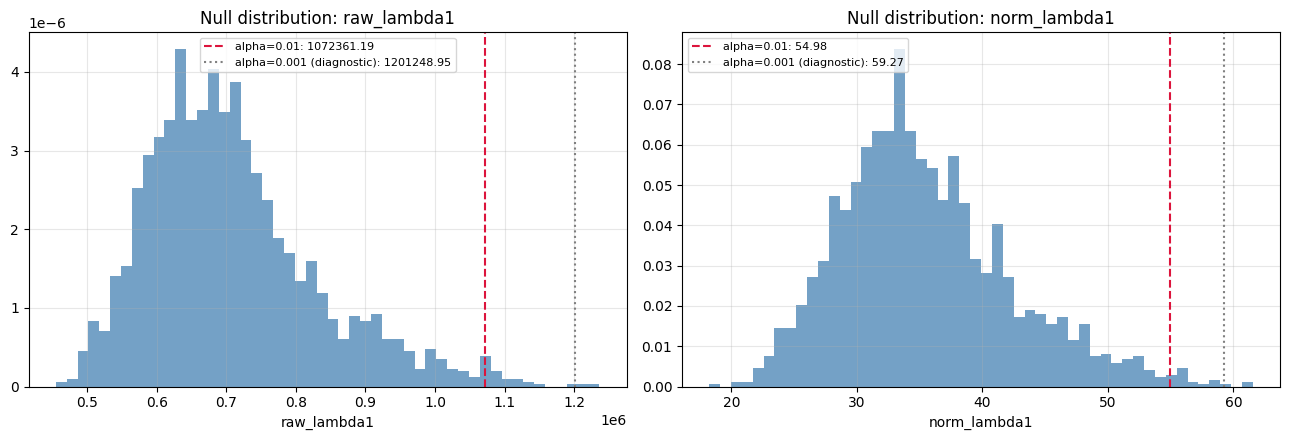


Saved -> /content/drive/MyDrive/gw_postmerger/nb3_artifacts/null_calibration.npz


In [ ]:
# ---------------------------------------------------------------------------
# 6. Null calibration -- all statistics
# ---------------------------------------------------------------------------
N_CALIBRATION = 2000
ALPHA_PRIMARY = 0.01
ALPHA_DIAGNOSTIC = 0.001

null_stats = {name: np.empty(N_CALIBRATION) for name in STAT_NAMES}
for i in range(N_CALIBRATION):
    w, _ = make_noise_only_window('calib_block')
    s = compute_window_statistics(w)
    for name in STAT_NAMES:
        null_stats[name][i] = s[name]
    if (i + 1) % 500 == 0:
        print(f"  calibrated {i+1}/{N_CALIBRATION}...")

for name in STAT_NAMES:
    assert np.all(np.isfinite(null_stats[name])), f"Null calibration contains non-finite {name} values."

thresholds_primary, thresholds_diagnostic, ci_primary = {}, {}, {}
n_expected_primary = ALPHA_PRIMARY * N_CALIBRATION
n_expected_diag = ALPHA_DIAGNOSTIC * N_CALIBRATION
print(f"\nalpha={ALPHA_PRIMARY}: ~{n_expected_primary:.0f} expected exceedances")
print(f"alpha={ALPHA_DIAGNOSTIC}: ~{n_expected_diag:.1f} expected exceedances (reference only)\n")

N_BOOTSTRAP = 500
for name in STAT_NAMES:
    vals = null_stats[name]
    thr_p = np.percentile(vals, 100 * (1 - ALPHA_PRIMARY))
    thr_d = np.percentile(vals, 100 * (1 - ALPHA_DIAGNOSTIC))
    thresholds_primary[name] = thr_p
    thresholds_diagnostic[name] = thr_d
    boot = np.array([np.percentile(rng.choice(vals, size=N_CALIBRATION, replace=True),
                                    100 * (1 - ALPHA_PRIMARY)) for _ in range(N_BOOTSTRAP)])
    ci_primary[name] = (np.percentile(boot, 2.5), np.percentile(boot, 97.5))
    print(f"{name:18s}: alpha=0.01 threshold={thr_p:.4f}  95% CI=[{ci_primary[name][0]:.4f}, "
          f"{ci_primary[name][1]:.4f}]   |  alpha=0.001 reference={thr_d:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, name in zip(axes, ['raw_lambda1', 'norm_lambda1']):
    ax.hist(null_stats[name], bins=50, color='steelblue', alpha=0.75, density=True)
    ax.axvline(thresholds_primary[name], color='crimson', ls='--',
                label=f'alpha=0.01: {thresholds_primary[name]:.2f}')
    ax.axvline(thresholds_diagnostic[name], color='gray', ls=':',
                label=f'alpha=0.001 (diagnostic): {thresholds_diagnostic[name]:.2f}')
    ax.set_title(f'Null distribution: {name}')
    ax.set_xlabel(name); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_null_distributions.pdf'))
plt.show()

np.savez(os.path.join(OUT_DIR, 'null_calibration.npz'),
         **{f'null_{name}': null_stats[name] for name in STAT_NAMES},
         **{f'thr01_{name}': thresholds_primary[name] for name in STAT_NAMES},
         **{f'thr001_{name}': thresholds_diagnostic[name] for name in STAT_NAMES})
print(f"\nSaved -> {os.path.join(OUT_DIR, 'null_calibration.npz')}")


## 7. Graph statistic versus total power

At a fixed SNR, sample noise-only windows and injections with several damping times, then compare total
power with the leading eigenvalue. Pearson and Spearman correlations summarize how much information the
two statistics share; the scatter plot also shows whether categories separate at similar power.


[Raw: power vs. lambda_1] Pearson r=0.173, Spearman r=0.230
[Normalized: power vs. lambda_1] Pearson r=0.139, Spearman r=0.132


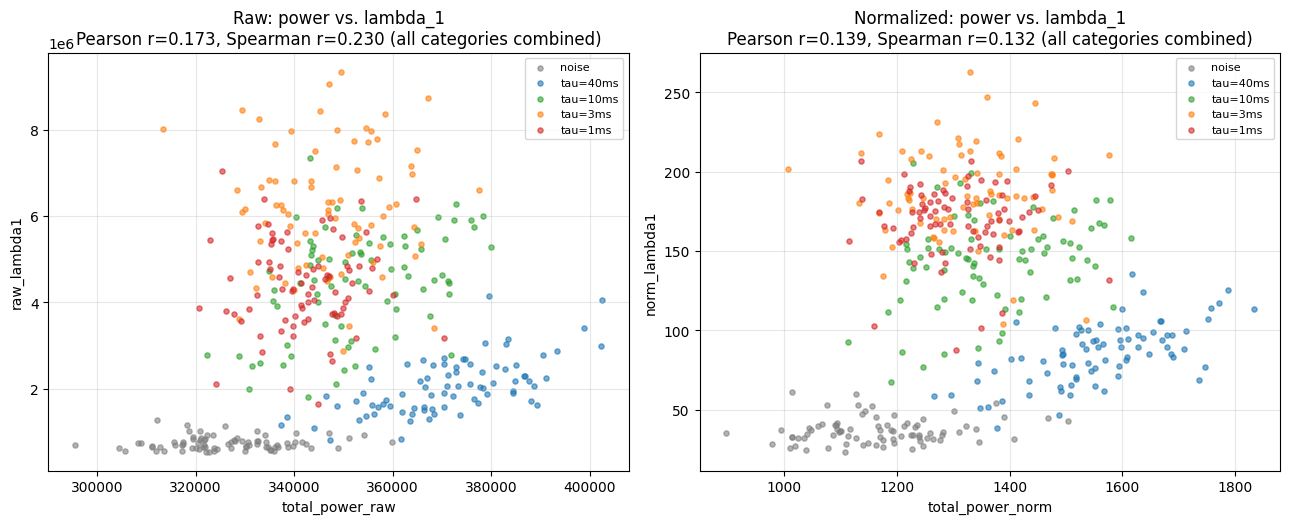


Interpretation note:
Compare category separation at similar total power.
Vertical separation at fixed power indicates information not captured by power alone.
If the points collapse onto one curve, the two statistics are largely redundant.
Use the correlation values together with the scatter plot.


In [ ]:
# ---------------------------------------------------------------------------
# 7. Power vs. lambda_1 scatter + correlation
# ---------------------------------------------------------------------------
SCATTER_SNR = 15.0
N_SCATTER_PER_CATEGORY = 80
SCATTER_TAUS_MS = [None, 40, 10, 3, 1]  # None = pure noise
SCATTER_COLORS = {'noise': 'gray', 'tau=40ms': 'tab:blue', 'tau=10ms': 'tab:green',
                   'tau=3ms': 'tab:orange', 'tau=1ms': 'tab:red'}

scatter_records = []
for tau_ms in SCATTER_TAUS_MS:
    label = 'noise' if tau_ms is None else f'tau={tau_ms}ms'
    for _ in range(N_SCATTER_PER_CATEGORY):
        if tau_ms is None:
            w, _ = make_noise_only_window('calib_block')
        else:
            f_peak = rng.uniform(1500.0, 4000.0)
            w, _, _ = inject_and_whiten('calib_block', f_peak=f_peak, tau=tau_ms / 1000.0,
                                         target_snr=SCATTER_SNR)
        s = compute_window_statistics(w)
        s['category'] = label
        scatter_records.append(s)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, power_key, lam_key, title in [
        (axes[0], 'total_power_raw', 'raw_lambda1', 'Raw: power vs. lambda_1'),
        (axes[1], 'total_power_norm', 'norm_lambda1', 'Normalized: power vs. lambda_1')]:
    for label, color in SCATTER_COLORS.items():
        xs = [r[power_key] for r in scatter_records if r['category'] == label]
        ys = [r[lam_key] for r in scatter_records if r['category'] == label]
        ax.scatter(xs, ys, s=14, alpha=0.6, color=color, label=label)
    all_x = np.array([r[power_key] for r in scatter_records])
    all_y = np.array([r[lam_key] for r in scatter_records])
    r_pearson = np.corrcoef(all_x, all_y)[0, 1]
    from scipy.stats import spearmanr
    r_spearman = spearmanr(all_x, all_y).correlation
    ax.set_xlabel(power_key); ax.set_ylabel(lam_key)
    ax.set_title(f'{title}\nPearson r={r_pearson:.3f}, Spearman r={r_spearman:.3f} (all categories combined)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    verdict = ("very high -- lambda_1 is likely near-redundant with power" if abs(r_pearson) > 0.95 else
               "high -- substantial shared information, but check category separation at fixed power" if abs(r_pearson) > 0.85 else
               "moderate/low -- lambda_1 appears to carry information beyond total power")
    print(f"[{title}] Pearson r={r_pearson:.3f}, Spearman r={r_spearman:.3f}")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_power_vs_lambda1_scatter.pdf'))
plt.show()

print("\nInterpretation note:")
print("Compare category separation at similar total power.")
print("Vertical separation at fixed power indicates information not captured by power alone.")
print("If the points collapse onto one curve, the two statistics are largely redundant.")
print("Use the correlation values together with the scatter plot.")


### 7b. Raw versus normalized leading eigenvalue

Compare `raw_lambda1` with `norm_lambda1` on the same sample. This shows whether empirical tile
normalization substantially changes the ranking of windows or mostly preserves it.


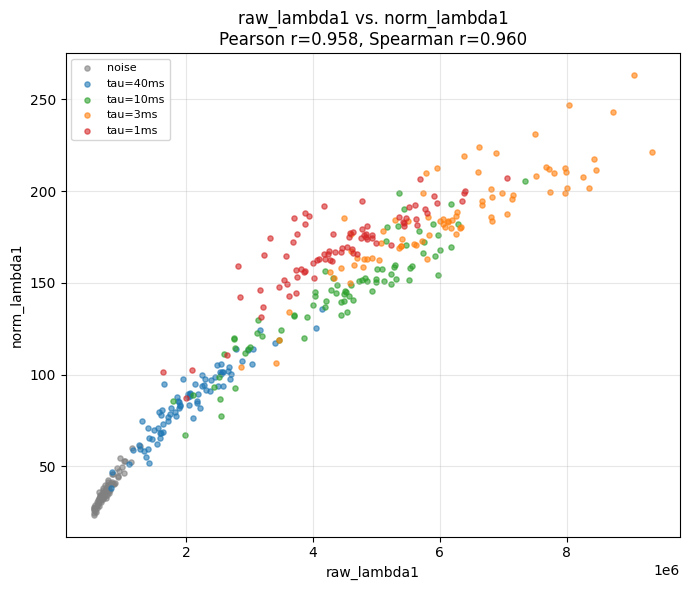

raw_lambda1 vs. norm_lambda1: Pearson r=0.958, Spearman r=0.960
Rank correlation is very high.
Normalization leaves the overall ordering nearly unchanged.
Any sensitivity difference is therefore a refinement of a similar ranking.
Both versions are kept for comparison.


In [ ]:
# ---------------------------------------------------------------------------
# 7b. raw_lambda1 vs. norm_lambda1
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
for label, color in SCATTER_COLORS.items():
    xs = [r['raw_lambda1'] for r in scatter_records if r['category'] == label]
    ys = [r['norm_lambda1'] for r in scatter_records if r['category'] == label]
    ax.scatter(xs, ys, s=14, alpha=0.6, color=color, label=label)

all_x = np.array([r['raw_lambda1'] for r in scatter_records])
all_y = np.array([r['norm_lambda1'] for r in scatter_records])
r_pearson = np.corrcoef(all_x, all_y)[0, 1]
from scipy.stats import spearmanr
r_spearman = spearmanr(all_x, all_y).correlation

ax.set_xlabel('raw_lambda1'); ax.set_ylabel('norm_lambda1')
ax.set_title(f'raw_lambda1 vs. norm_lambda1\nPearson r={r_pearson:.3f}, Spearman r={r_spearman:.3f}')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'plot_raw_vs_norm_lambda1_scatter.pdf'))
plt.show()

print(f"raw_lambda1 vs. norm_lambda1: Pearson r={r_pearson:.3f}, Spearman r={r_spearman:.3f}")
if r_spearman > 0.95:
    print("Rank correlation is very high.")
    print("Normalization leaves the overall ordering nearly unchanged.")
    print("Any sensitivity difference is therefore a refinement of a similar ranking.")
    print("Both versions are kept for comparison.")
elif r_spearman > 0.8:
    print("Rank correlation is high but not complete.")
    print("Normalization changes some window rankings.")
    print("The broad ordering is still similar.")
else:
    print("Rank correlation is moderate.")
    print("Normalization changes the ranking substantially.")
    print("Inspect the reordered windows before drawing a stronger interpretation.")


## 8. `(SNR, tau)` sweep

Run the full grid on `train_block` noise and save every per-window statistic in
`stats_grid[stat][tau_idx, snr_idx, sample_idx]`.

For the three headline statistics, compute `P_det` relative to the `alpha=0.01` null threshold, Wilson
confidence intervals, and a simple monotonicity diagnostic across SNR.


In [ ]:
# ---------------------------------------------------------------------------
# 8. Phase-diagram sweep -- full per-sample stats, all statistics
# ---------------------------------------------------------------------------
TAU_GRID_MS = [1, 3, 5, 10, 20, 40]
SNR_GRID = [4, 6, 8, 10, 12, 15, 18, 22, 26, 30]
N_PER_CELL = 40
PHASE_STATS = ['total_power_raw', 'raw_lambda1', 'norm_lambda1']  # statistics shown in the phase diagrams

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (0.0, 1.0)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2)) / denom
    return (max(0.0, center - margin), min(1.0, center + margin))

n_tau, n_snr = len(TAU_GRID_MS), len(SNR_GRID)
stats_grid = {name: np.empty((n_tau, n_snr, N_PER_CELL)) for name in STAT_NAMES}

for i, tau_ms in enumerate(TAU_GRID_MS):
    for j, snr in enumerate(SNR_GRID):
        for k in range(N_PER_CELL):
            f_peak = rng.uniform(1500.0, 4000.0)
            w, _, _ = inject_and_whiten('train_block', f_peak=f_peak, tau=tau_ms / 1000.0,
                                         target_snr=float(snr))
            s = compute_window_statistics(w)
            for name in STAT_NAMES:
                stats_grid[name][i, j, k] = s[name]
    print(f"  tau={tau_ms:3d}ms done")

for name in STAT_NAMES:
    assert np.all(np.isfinite(stats_grid[name])), f"stats_grid[{name}] contains non-finite values."

np.savez(os.path.join(OUT_DIR, 'sweep_full_stats.npz'),
         tau_grid_ms=np.array(TAU_GRID_MS), snr_grid=np.array(SNR_GRID),
         **{f'stats_{name}': stats_grid[name] for name in STAT_NAMES})
print(f"\nSaved per-sample sweep statistics -> {os.path.join(OUT_DIR, 'sweep_full_stats.npz')}")
print(f"Shape per statistic: {stats_grid[STAT_NAMES[0]].shape} (n_tau x n_snr x N_PER_CELL)")


  tau=  1ms done
  tau=  3ms done
  tau=  5ms done
  tau= 10ms done
  tau= 20ms done
  tau= 40ms done

Saved per-sample sweep statistics -> /content/drive/MyDrive/gw_postmerger/nb3_artifacts/sweep_full_stats.npz
Shape per statistic: (6, 10, 40) (n_tau x n_snr x N_PER_CELL)


In [ ]:
# ---------------------------------------------------------------------------
# P_det, Wilson CI, and monotonicity diagnostics
# ---------------------------------------------------------------------------
p_det = {name: np.zeros((n_tau, n_snr)) for name in PHASE_STATS}
p_det_ci_lo = {name: np.zeros((n_tau, n_snr)) for name in PHASE_STATS}
p_det_ci_hi = {name: np.zeros((n_tau, n_snr)) for name in PHASE_STATS}

for name in PHASE_STATS:
    thr = thresholds_primary[name]
    for i in range(n_tau):
        for j in range(n_snr):
            k = int(np.sum(stats_grid[name][i, j, :] > thr))
            p_det[name][i, j] = k / N_PER_CELL
            lo, hi = wilson_ci(k, N_PER_CELL)
            p_det_ci_lo[name][i, j] = lo
            p_det_ci_hi[name][i, j] = hi

print("Monotonicity check: decreases larger than 2 pooled standard errors are flagged.\n")
print("")
for name in PHASE_STATS:
    print(f"--- {name} ---")
    any_violation = False
    for i, tau_ms in enumerate(TAU_GRID_MS):
        se = np.sqrt(p_det[name][i, :] * (1 - p_det[name][i, :]) / N_PER_CELL)
        for j in range(n_snr - 1):
            tol = 2.0 * np.sqrt(se[j]**2 + se[j + 1]**2)
            if p_det[name][i, j] > p_det[name][i, j + 1] + tol:
                any_violation = True
                print(f"  tau={tau_ms}ms: P_det(SNR={SNR_GRID[j]})={p_det[name][i,j]:.2f} > "
                      f"P_det(SNR={SNR_GRID[j+1]})={p_det[name][i,j+1]:.2f}; "
                      f"tolerance={tol:.2f}")
    if not any_violation:
        print("  No violations beyond sampling tolerance.")

np.savez(os.path.join(OUT_DIR, 'phase_diagram_p_det.npz'),
         tau_grid_ms=np.array(TAU_GRID_MS), snr_grid=np.array(SNR_GRID),
         **{f'p_det_{name}': p_det[name] for name in PHASE_STATS},
         **{f'ci_lo_{name}': p_det_ci_lo[name] for name in PHASE_STATS},
         **{f'ci_hi_{name}': p_det_ci_hi[name] for name in PHASE_STATS})
print(f"\nSaved -> {os.path.join(OUT_DIR, 'phase_diagram_p_det.npz')}")


Monotonicity check: decreases larger than 2 pooled standard errors are flagged.


--- total_power_raw ---
  tau=3ms: P_det(SNR=6)=0.10 > P_det(SNR=8)=0.00; tolerance=0.09
--- raw_lambda1 ---
  No violations beyond sampling tolerance.
--- norm_lambda1 ---
  No violations beyond sampling tolerance.

Saved -> /content/drive/MyDrive/gw_postmerger/nb3_artifacts/phase_diagram_p_det.npz


## 9. Phase diagrams

Plot `P_det(SNR, tau)` for `total_power_raw`, `raw_lambda1`, and `norm_lambda1` side by side. The
comparison is intended to show whether the graph-based statistics behave differently from the simpler
power baseline.


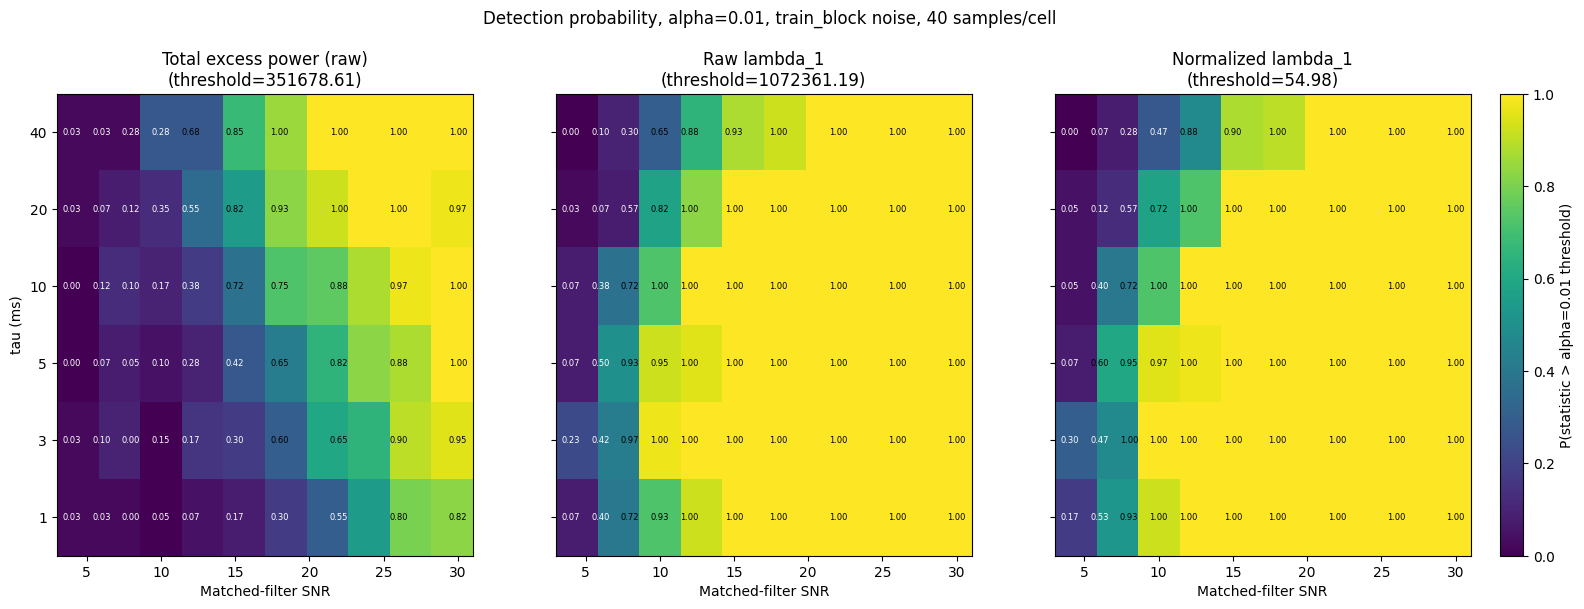

In [ ]:
# ---------------------------------------------------------------------------
# Three-panel phase diagram
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(19, 6), sharey=True)
titles = {'total_power_raw': 'Total excess power (raw)', 'raw_lambda1': 'Raw lambda_1',
          'norm_lambda1': 'Normalized lambda_1'}
for ax, name in zip(axes, PHASE_STATS):
    im = ax.imshow(p_det[name], aspect='auto', origin='lower', cmap='viridis', vmin=0, vmax=1,
                    extent=[min(SNR_GRID) - 1, max(SNR_GRID) + 1, -0.5, n_tau - 0.5])
    ax.set_yticks(range(n_tau)); ax.set_yticklabels([str(t) for t in TAU_GRID_MS])
    ax.set_xlabel('Matched-filter SNR')
    ax.set_title(f'{titles[name]}\n(threshold={thresholds_primary[name]:.2f})')
    for i in range(n_tau):
        for j in range(n_snr):
            ax.text(SNR_GRID[j], i, f'{p_det[name][i,j]:.2f}', ha='center', va='center', fontsize=6,
                    color='white' if p_det[name][i, j] < 0.6 else 'black')
axes[0].set_ylabel('tau (ms)')
fig.colorbar(im, ax=axes, label='P(statistic > alpha=0.01 threshold)', fraction=0.02, pad=0.02)
plt.suptitle(f'Detection probability, alpha=0.01, train_block noise, {N_PER_CELL} samples/cell', y=1.02)
plt.savefig(os.path.join(OUT_DIR, 'plot_phase_diagram_comparison.pdf'), bbox_inches='tight')
plt.show()


## 10. Artifacts saved by this notebook

```text
nb3_artifacts/
  plot_null_distributions.pdf
  null_calibration.npz
  plot_power_vs_lambda1_scatter.pdf
  plot_raw_vs_norm_lambda1_scatter.pdf
  sweep_full_stats.npz
  phase_diagram_p_det.npz
  plot_phase_diagram_comparison.pdf
```

`null_calibration.npz` contains the full null samples and thresholds for all seven statistics.
`sweep_full_stats.npz` contains the per-sample grid values, while `phase_diagram_p_det.npz` contains
`P_det` and Wilson intervals for the three headline statistics.

The correlation plots in Section 7 are useful when interpreting the graph statistic relative to total
power. This notebook is limited to Stage-1 detectability; it does not estimate a physical damping time,
and `test_block` remains unused.
